## Train a Custom Model

This tutorial shows how to train a custom ResNet on CIFAR-100 with **RoundPipe** from scratch.

You will learn:

1. How to rewrite a model as `nn.Sequential` so RoundPipe can pipeline it layer by layer.
2. How to set up mixed-precision training with `RoundPipe` + `OptimizerCtx`, using FP16 model weights and an FP32 optimizer.
3. How to train with the fused `forward_backward()` API, and why `synchronize()` is needed before evaluation to refresh the model state.

RoundPipe can automatically assign pipeline stages across multiple GPUs, so the same code runs unchanged on either 1 GPU or 8 GPUs.

This notebook is intended to demonstrate the RoundPipe workflow. Because RoundPipe is not designed for small models, training may be slower than a conventional single-machine implementation.

### 1. Environment Setup

Install `PyTorch`, `torchvision`, `matplotlib`, `tqdm`, and `roundpipe`.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

from roundpipe import RoundPipe, OptimizerCtx, GradScaler
from roundpipe.optim import Adam

### 2. Express ResNet as `nn.Sequential`

RoundPipe works by splitting a model into layers and executing them across different GPUs and time steps. To let RoundPipe partition the network automatically, we write the model as `nn.Sequential`.

In [2]:
# ResNet Basic Block
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


def make_blocks(in_channels, out_channels, blocks, stride):
    layers = []
    layers.append(BasicBlock(in_channels, out_channels, stride))
    for _ in range(1, blocks):
        layers.append(BasicBlock(out_channels, out_channels))
    return layers


def build_resnet(num_classes=100):
    layers = [
        nn.Conv2d(3, 32, 3, 1, 1, bias=False),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        *make_blocks(32, 64, 3, 2),
        *make_blocks(64, 128, 4, 2),
        *make_blocks(128, 256, 6, 2),
        *make_blocks(256, 512, 3, 2),
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(512, num_classes),
    ]
    return nn.Sequential(*layers)

### 3. Prepare the CIFAR-100 Data

Use `RandomCrop`, `RandomHorizontalFlip`, and normalization for the training set. Apply normalization only to the test set.

In [3]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, 4),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

trainset = datasets.CIFAR100(root="./data", train=True, download=True, transform=transform_train)
testset  = datasets.CIFAR100(root="./data", train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader  = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

### 4. Wrap the Model with RoundPipe

Pass the `nn.Sequential` model directly to `RoundPipe`. Create the optimizer inside `OptimizerCtx()` so it is attached to the correct parameters.

In [4]:
model = RoundPipe(build_resnet().to(torch.float16), optim_dtype=torch.float32)

with OptimizerCtx():
    optimizer = Adam(model.parameters())

scaler = GradScaler()
criterion = nn.CrossEntropyLoss()

### 5. Evaluation Function

Call `model.synchronize()` before evaluation. During training, optimizer updates run asynchronously by default, so the parameters currently used for execution can lag one step behind the optimizer-owned parameters. `synchronize()` waits for pending updates and refreshes the model with the latest weights.

In [5]:
def evaluate(loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(torch.float16), labels
            outputs = model(images)
            loss = criterion(outputs.float(), labels)
            loss_sum += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return loss_sum / total, correct / total

### 6. Training Loop

The core training API in RoundPipe is `forward_backward(...)`. It combines the forward and backward passes into a single call, then overlaps them across GPUs to reduce pipeline bubbles.

A few details:

- Dividing `loss_fn` by `(num_devices + 1)` normalizes the loss by the number of microbatches, since the default is `num_microbatch = num_devices + 1`.
- `model.step(step_fn)` triggers the optimizer update asynchronously by default (`is_async=True`), and the callback runs on the optimizer thread.
- `scaler.update()` adjusts the loss scale for the next step.

In [6]:
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

def optimizer_step():
    scaler.step(optimizer)
    optimizer.zero_grad()

EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
        loss, outputs = model.forward_backward(
            input_args=(images.to(torch.float16),),
            label=labels,
            loss_fn=lambda outputs, labels: scaler.scale(
                criterion(outputs.float(), labels)
            ) / (torch.cuda.device_count() + 1),
            return_outputs=True,
        )
        model.step(optimizer_step)
        scaler.update()

        loss_item = loss.item() / scaler.get_scale()
        running_loss += loss_item * labels.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    test_loss, test_acc = evaluate(testloader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )

Epoch 01/20 | Train Loss: 4.3328 | Train Acc: 0.0413 | Test Loss: 3.9271 | Test Acc: 0.0791


Epoch 02/20 | Train Loss: 3.7637 | Train Acc: 0.1099 | Test Loss: 3.4888 | Test Acc: 0.1579


Epoch 03/20 | Train Loss: 3.3601 | Train Acc: 0.1793 | Test Loss: 3.0630 | Test Acc: 0.2373


Epoch 04/20 | Train Loss: 3.0545 | Train Acc: 0.2372 | Test Loss: 2.7539 | Test Acc: 0.2966


Epoch 05/20 | Train Loss: 2.7554 | Train Acc: 0.2927 | Test Loss: 2.5448 | Test Acc: 0.3400


...

Epoch 16/20 | Train Loss: 1.2177 | Train Acc: 0.6443 | Test Loss: 1.5081 | Test Acc: 0.5903


Epoch 17/20 | Train Loss: 1.1500 | Train Acc: 0.6630 | Test Loss: 1.4463 | Test Acc: 0.6080


Epoch 18/20 | Train Loss: 1.0774 | Train Acc: 0.6808 | Test Loss: 1.4315 | Test Acc: 0.6115


Epoch 19/20 | Train Loss: 1.0130 | Train Acc: 0.6965 | Test Loss: 1.4786 | Test Acc: 0.6077


Epoch 20/20 | Train Loss: 0.9505 | Train Acc: 0.7124 | Test Loss: 1.4499 | Test Acc: 0.6189


### 7. Visualize the Training Curves

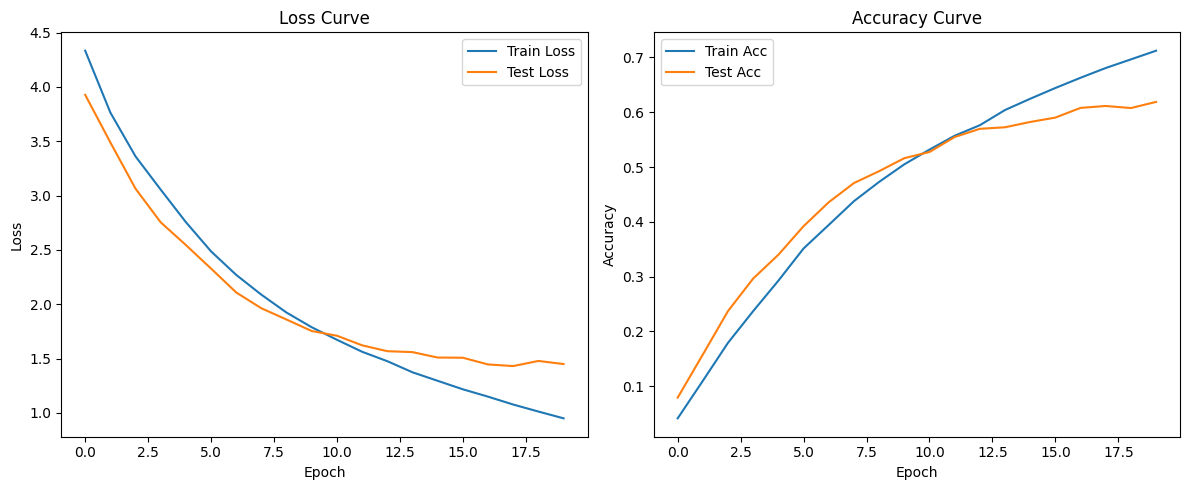

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(test_losses, label="Test Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].set_title("Loss Curve")
axes[1].plot(train_accs, label="Train Acc")
axes[1].plot(test_accs, label="Test Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_title("Accuracy Curve")
plt.tight_layout()
plt.show()

### Summary

This notebook walks through the smallest complete example of training a ResNet with RoundPipe:

1. **Sequential model**: ResNet is rewritten as `nn.Sequential` in the form `Conv → BasicBlock × N → ClassifierHead`, so each block can naturally become a pipeline stage.
2. **Mixed precision**: The model runs in FP16 while the optimizer stays in FP32, using `OptimizerCtx` together with `roundpipe.optim.Adam`.
3. **Fused forward/backward**: `forward_backward()` keeps the training loop nearly as simple as standard single-GPU PyTorch, while RoundPipe handles multi-GPU pipeline scheduling underneath. `model.step()` launches optimizer updates asynchronously, and `model.synchronize()` refreshes parameters before evaluation.

If you have more GPUs, you do not need to change the code. RoundPipe will generate a pipeline plan automatically based on the available devices. You can further control the number of microbatches with `run_config=RoundPipeRunConfig(num_microbatch=...)`.